# NumPy et Matplotlib

Ce notebook couvre les deux piliers de la stack data science Python :
- **NumPy** : le moteur de calcul numérique (opérations vectorisées, pas de boucles)
- **Matplotlib** : la bibliothèque de visualisation de référence

À la fin de ce notebook, vous saurez créer et manipuler des tableaux NumPy, effectuer des calculs vectorisés, et produire des graphiques pour explorer vos données.

NumPy (Numerical Python) est le noyau du calcul scientifique en Python. Il met à disposition un objet central — le **ndarray** (n-dimensional array) — qui permet de stocker et manipuler des tableaux de données numériques de façon extrêmement rapide.

Pourquoi pas des listes Python ? Parce que NumPy effectue les opérations en C sous le capot, sur des blocs de mémoire contigus. Résultat : les calculs sont **50 à 100 fois plus rapides** qu'avec des boucles Python classiques. C'est ce qu'on appelle la **vectorisation**.

Pour utiliser NumPy, on importe le package avec l'alias conventionnel `np` :

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np

L'alias `np` est une **convention universelle** : tous les tutoriels, la documentation et vos collègues l'utilisent. Si vous écrivez `numpy.array(...)` au lieu de `np.array(...)`, le code marchera, mais il sera plus verbeux et moins lisible.

## Les Arrays (tableaux)

En data science, vos données sont presque toujours des tableaux de nombres. L'array NumPy est conçu exactement pour ça.

Un array NumPy est une grille de valeurs **du même type**, indexées par un tuple d'entiers. L'attribut `shape` donne les dimensions du tableau — c'est la première chose à vérifier quand on manipule des données.

En ML, un dataset classique est un array 2D : chaque **ligne** est un exemple (un passager, un client, une transaction), chaque **colonne** est une caractéristique (feature).

On peut créer un array à partir d'une liste Python. L'accès aux éléments se fait avec la notation `[]` (comme les listes, mais en plus puissant) :

In [2]:
a = np.array([1, 2, 3])  #  Création d'un tableau 1 dimension
print(type(a), a.shape, a[0], a[1], a[2])
a[0] = 5                 # Modification de l'un des éléments
print(a)                 

<class 'numpy.ndarray'> (3,) 1 2 3
[5 2 3]


In [3]:
b = np.array([[1,2,3],[4,5,6]])   # Création d'un tableau à 2 dimensions
print(b)
b.shape

[[1 2 3]
 [4 5 6]]


(2, 3)

In [4]:
print(b.shape)                   
print(b[0, 0], b[0, 1], b[1, 0])

(2, 3)
1 2 4


NumPy propose plusieurs fonctions pour créer des tableaux pré-remplis. Chacune a un usage typique :

| Fonction | Crée | Usage typique |
|----------|------|---------------|
| `np.zeros(shape)` | Tableau de 0 | Initialiser un tableau qu'on va remplir ensuite |
| `np.ones(shape)` | Tableau de 1 | Créer un vecteur de biais, des poids initiaux |
| `np.full(shape, val)` | Tableau d'une valeur | Remplir avec une constante (ex: valeur par défaut) |
| `np.eye(n)` | Matrice identité | Algèbre linéaire, régularisation |
| `np.random.random(shape)` | Valeurs aléatoires [0, 1) | Initialiser des poids, générer des données de test |

In [5]:
a = np.zeros((2,2))  # Création d'un tableau ne contenant que des 0
print(a)

[[0. 0.]
 [0. 0.]]


In [6]:
b = np.ones((1,2))   # Création d'un tableau ne contenant que des 1
print(b)

[[1. 1.]]


In [7]:
c = np.full((2,2), 7.) # Création d'un tableau ne contenant que des 7.0
print(c) 

[[7. 7.]
 [7. 7.]]


In [8]:
d = np.eye(2)       # Création d'un matrice unité de deux dimensions
print(d)

[[1. 0.]
 [0. 1.]]


In [9]:
e = np.random.random((2,2)) # Création d'un tableau ne contenant que des valeurs aléatoires
print(e)

[[0.49902916 0.86178152]
 [0.01746163 0.07163377]]


### Indexation et slicing

L'indexation est un outil fondamental : c'est comme ça que vous sélectionnez des sous-ensembles de vos données. NumPy offre plusieurs méthodes puissantes.

NumPy propose plusieurs façons de manipuler les données d'un tableau. La plus courante est le **slicing** (découpage).

**Slicing** : on découpe un tableau en précisant la "tranche" à extraire sur chacune des dimensions. La syntaxe est `[début:fin]` où `fin` est **exclu** (comme les listes Python) :

In [10]:
import numpy as np

# Création d'un tableau à deux dimensions et de taille (3,4)
a = np.array([[1,2,3,4], [5,6,7,8], [9,10,11,12]])
print(a)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]


In [11]:
# On souhaite "trancher" le tableau pour récupérer les lignes jusqu'à 2 (2 exclu) et les colonnes de 1 à 3 (3 exclus)
b = a[:2, 1:3]
print(b)

[[2 3]
 [6 7]]


> **Attention : les slices sont des vues, pas des copies !** Le tableau `b` contient des références vers `a`. Modifier `b` modifie aussi `a`. C'est un piège classique — si vous voulez une copie indépendante, utilisez `b = a[:2, 1:3].copy()`.

In [12]:
print(a[0, 1])  
b[0, 0] = 77    # b[0, 0] référence a[0, 1]
print(a[0, 1]) 

2
77


**Piège important** — la syntaxe du slicing change la **dimension** du résultat :

- `a[1, :]` → retourne un array **1D** de shape `(4,)` — la dimension "ligne" disparaît
- `a[1:2, :]` → retourne un array **2D** de shape `(1, 4)` — la dimension "ligne" est conservée

En ML, cette différence compte : certains algorithmes attendent un array 2D et planteront silencieusement si vous passez un 1D. Quand vous avez un doute, vérifiez toujours `.shape` :

In [13]:
row_r1 = a[1, :]    # Vue en une dimension de la deuxième ligne 
row_r2 = a[1:2, :]  # Vue en deux dimensions de la deuxième ligne 
row_r3 = a[[1], :]  # Vue en deux dimensions de la deuxième ligne 
print(row_r1, row_r1.shape) 
print(row_r2, row_r2.shape)
print(row_r3, row_r3.shape)

[5 6 7 8] (4,)
[[5 6 7 8]] (1, 4)
[[5 6 7 8]] (1, 4)


In [14]:
# Idem quand on accède aux colonnes :
col_r1 = a[:, 1]
col_r2 = a[:, 1:2]
print(col_r1, col_r1.shape)
print()
print(col_r2, col_r2.shape)

[77  6 10] (3,)

[[77]
 [ 6]
 [10]] (3, 1)


### Fancy indexing (indexation par tableau)

Le fancy indexing permet de sélectionner des éléments **spécifiques** en passant un tableau d'indices. C'est utile par exemple pour :
- Sélectionner une colonne différente pour chaque ligne (ex: la colonne de la classe prédite pour chaque échantillon)
- Réordonner les lignes d'un dataset
- Extraire des éléments à des positions arbitraires

In [15]:
# Le tableau d'origine
a = np.array([[1,2,3], [4,5,6], [7,8,9], [10, 11, 12]])
print(a)

[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]


In [16]:
# Ce tableau contient des indices qui vont être utilisés ensuite
b = np.array([0, 2, 0, 1])

# Utilise le tableau précédent afin de sélectionner un élément par ligne
print(a[np.arange(4), b])

[ 1  6  7 11]


In [17]:
# Modifie un élément par ligne en utilisant les indices de b
a[np.arange(4), b] += 10
print(a)

[[11  2  3]
 [ 4  5 16]
 [17  8  9]
 [10 21 12]]


### Indexation booléenne (boolean indexing)

C'est l'un des patterns les plus utilisés en data science — l'équivalent d'un `WHERE` en SQL. On crée un **masque** (tableau de `True`/`False`) et on l'utilise pour filtrer :

In [18]:
import numpy as np

a = np.array([[1,2], [3, 4], [5, 6]])

bool_idx = (a > 2)  
print(bool_idx)

[[False False]
 [ True  True]
 [ True  True]]


In [19]:
# On peut construire un tableau de une dimension contenant les valeurs qui corresponent à l'indexation booléenne

print(a)
print(a[bool_idx])

# Le raccourci suivant est possible
print(a[a > 2])

[[1 2]
 [3 4]
 [5 6]]
[3 4 5 6]
[3 4 5 6]


### Slicing avec pas (step)

En plus de `[début:fin]`, on peut ajouter un **pas** (step) : `[début:fin:pas]`. C'est utile pour sous-échantillonner des données ou inverser un tableau :

In [20]:
# On peut sélectionner un élément sur deux d'un tableau

x = np.arange(0, 10)
print(x)
print(x[::2])

[0 1 2 3 4 5 6 7 8 9]
[0 2 4 6 8]


In [21]:
# La même chose, mais à partir du 4ème élément

x = np.arange(0, 10)
print(x)
print(x[3::2])

[0 1 2 3 4 5 6 7 8 9]
[3 5 7 9]


In [22]:
# Dans l'exemple précédent, 2 représente un incrément.
# En fournissant un incrément négatif, on indique qu'on veut commencer par la fin

x = np.arange(0, 10)
print(x)
print(x[::-2])

[0 1 2 3 4 5 6 7 8 9]
[9 7 5 3 1]


In [23]:
# Ce qui peut servir à inverser l'ordre d'un tableau

x = np.arange(0, 10)
print(x)
print(x[::-1])

[0 1 2 3 4 5 6 7 8 9]
[9 8 7 6 5 4 3 2 1 0]


### Type des données (dtype)

Contrairement aux listes Python qui peuvent mélanger les types, un array NumPy contient des éléments **du même type**. C'est cette contrainte qui lui permet d'être aussi rapide.

Par défaut, NumPy devine le type de vos données. Mais vous pouvez le forcer explicitement avec le paramètre `dtype` — utile quand vous voulez contrôler la précision (et donc la mémoire utilisée) :

In [24]:
x = np.array([1, 2])  # choisi par numpy
y = np.array([1.0, 2.0])  # choisi par numpy
z = np.array([1, 2], dtype=np.float64)  # on force le type

print (x.dtype, y.dtype, z.dtype)

int64 float64 float64


Voir la [documentation complète des dtypes](http://docs.scipy.org/doc/numpy/reference/arrays.dtypes.html).

### Calculs mathématiques sur les tableaux

Toutes les opérations arithmétiques s'appliquent **élément par élément** (element-wise). C'est la vectorisation en action — pas besoin de boucle `for` :

In [25]:
x = np.array([[1,2],[3,4]], dtype=np.float64)
y = np.array([[5,6],[7,8]], dtype=np.float64)

# Addition
print(x + y)
print(np.add(x, y))

[[ 6.  8.]
 [10. 12.]]
[[ 6.  8.]
 [10. 12.]]


In [26]:
# Différence
print(x - y)
print(np.subtract(x, y))

[[-4. -4.]
 [-4. -4.]]
[[-4. -4.]
 [-4. -4.]]


In [27]:
# Produits des éléments (ATTENTION : ce n'est pas un produit matriciel ! cf ci-dessous)
print(x * y)
print(np.multiply(x, y))

[[ 5. 12.]
 [21. 32.]]
[[ 5. 12.]
 [21. 32.]]


In [28]:
# Division membre à membre
print(x / y)
print(np.divide(x, y))

[[0.2        0.33333333]
 [0.42857143 0.5       ]]
[[0.2        0.33333333]
 [0.42857143 0.5       ]]


### Produit matriciel (dot product)

Les opérations `+`, `-`, `*`, `/` vues ci-dessus sont **élément par élément** : chaque case de `x` est multipliée par la case correspondante de `y`. Ce n'est **pas** un produit matriciel.

Le **produit matriciel** (ou dot product) est une opération différente : pour chaque paire (ligne de la première matrice, colonne de la seconde), on multiplie les éléments un à un et on les additionne. C'est l'opération fondamentale de l'algèbre linéaire, et elle est au coeur de quasiment tous les algorithmes de ML.

**Exemple visuel** avec une matrice 2×2 et un vecteur de taille 2 :

```
x = [[1, 2],    v = [9, 10]
     [3, 4]]

x @ v = [1×9 + 2×10,  = [29,
         3×9 + 4×10]     67]
```

En NumPy, trois syntaxes équivalentes : `x @ v`, `x.dot(v)`, `np.dot(x, v)`. On recommande `@` (la plus lisible) :

In [29]:
x = np.array([[1,2],[3,4]])
y = np.array([[5,6],[7,8]])

v = np.array([9,10])
w = np.array([11, 12])

print(x @ v)

print(np.dot(v, w))
print(w.dot(v))

print(x.dot(v))
print(np.dot(x, v))

[29 67]
219
219
[29 67]
[29 67]


Détail de ce qui vient de se passer :

- `x @ v` : produit matrice (2×2) × vecteur (2,) → vecteur résultat (2,). C'est la syntaxe recommandée.
- `np.dot(v, w)` : produit scalaire de deux vecteurs 1D → un seul nombre (9×11 + 10×12 = 219).
- `x.dot(v)` et `np.dot(x, v)` : mêmes résultats que `x @ v`, syntaxes alternatives.

#### Vecteurs colonnes et vecteurs lignes

Quand on travaille avec `np.dot`, la **forme** (shape) des vecteurs détermine le résultat. Un array 1D `[9, 10]` n'a qu'une dimension — NumPy le traite tantôt comme ligne, tantôt comme colonne selon le contexte, ce qui peut être déroutant.

Pour éviter toute ambiguïté, on utilise des **matrices à une dimension** :
- Vecteur **colonne** : shape `(2, 1)` → `[[9], [10]]`
- Vecteur **ligne** : shape `(1, 2)` → `[[9, 10]]`
- `.T` (transposée) bascule de l'un à l'autre

In [30]:
v = np.array([[9], [10]])
w = np.array([[11, 12]])
print(v)
print(v.T)
print(w)

[[ 9]
 [10]]
[[ 9 10]]
[[11 12]]


In [31]:
print(v.dot(w))
print(w.dot(v))
print(v.T.dot(v))

[[ 99 108]
 [110 120]]
[[219]]
[[181]]


Détail des résultats :

- `v.dot(w)` : colonne (2×1) × ligne (1×2) → **matrice** (2×2). C'est un **produit extérieur**.
- `w.dot(v)` : ligne (1×2) × colonne (2×1) → **scalaire** dans une matrice (1×1). C'est un **produit scalaire**.
- `v.T.dot(v)` : ligne (1×2) × colonne (2×1) → scalaire (1×1). C'est la **norme au carré** du vecteur (9² + 10² = 181).

La forme du résultat dépend de l'ordre des opérandes — c'est la raison pour laquelle il faut contrôler les shapes.

`np.reshape` permet de convertir un array 1D en matrice. Le `-1` signifie "calcule cette dimension automatiquement" :

In [32]:
u = np.array([9,10])
v = u.reshape(-1, 1)
w = u.reshape(1, -1)
print(u)
print(v)
print(w)

[ 9 10]
[[ 9]
 [10]]
[[ 9 10]]


### Fonctions d'agrégation

NumPy offre des fonctions statistiques qui s'appliquent sur tout le tableau ou selon un axe. Le paramètre `axis` est crucial : `axis=0` agrège **par colonne** (le long des lignes), `axis=1` agrège **par ligne**.

Les fonctions les plus courantes — elles acceptent toutes le paramètre `axis` :

```python
x.sum()       # Somme
x.mean()      # Moyenne
x.std()       # Écart-type
x.min()       # Minimum
x.max()       # Maximum
np.median(x)  # Médiane
```

Exemple avec `axis` :

In [33]:
x = np.array([[1,2],[3,4]])

print(np.sum(x))  # Somme de tous les éléments
print(np.sum(x, axis=0))  # Somme selon l'axe des lignes
print(np.sum(x, axis=1))  # Somme selon l'axe des colonnes

10
[4 6]
[3 7]


Voir la [liste complète des fonctions mathématiques](http://docs.scipy.org/doc/numpy/reference/routines.math.html).

### Broadcasting : opérations entre tableaux de formes différentes

Le broadcasting est une fonctionnalité puissante de NumPy qui permet de faire des opérations entre des tableaux de **formes différentes**, sans copier de données.

**Règle simple :** quand NumPy compare les dimensions de deux tableaux de droite à gauche, il accepte l'opération si chaque dimension est soit identique, soit égale à 1.

```python
# Matrice (3×3) + vecteur (3,) → le vecteur est "étiré" sur chaque ligne
matrice = np.array([[1, 2, 3],
                    [4, 5, 6],
                    [7, 8, 9]])
vecteur = np.array([10, 20, 30])
matrice + vecteur
# → [[11, 22, 33],
#    [14, 25, 36],
#    [17, 28, 39]]

# Scalaire → broadcasted sur tout le tableau
matrice * 2
# → [[ 2,  4,  6],
#    [ 8, 10, 12],
#    [14, 16, 18]]
```

C'est le broadcasting qui permet d'écrire `(x - x.mean()) / x.std()` pour normaliser un dataset entier en une ligne — chaque élément est traité individuellement sans boucle.

## Matplotlib

Un chiffre seul ne dit pas grand-chose. "La moyenne est 29.7" — est-ce que la distribution est symétrique ? Y a-t-il des valeurs extrêmes ? Un graphique répond instantanément à ces questions.

Matplotlib est **la** bibliothèque de visualisation de référence en Python. Quasiment toutes les autres (Seaborn, Pandas `.plot()`) sont construites dessus.

Le module `matplotlib.pyplot` fournit une interface simple pour créer des graphiques. Par convention, on l'importe avec l'alias `plt` :

In [34]:
import matplotlib.pyplot as plt

La commande magique `%matplotlib inline` permet d'afficher les graphiques directement dans le notebook (au lieu d'ouvrir une fenêtre séparée) :

In [35]:
%matplotlib inline

### Graphiques de base

En exploration de données, les deux graphiques les plus courants pour commencer sont le **scatter plot** (relation entre deux variables) et le **line plot** (évolution d'une série). Matplotlib propose aussi des histogrammes, bar charts, etc. — on les utilisera plus tard avec Seaborn.

La fonction centrale de Matplotlib est `plot()`, qui trace des courbes en 2D. On peut aussi utiliser `scatter()` pour afficher des points individuels :

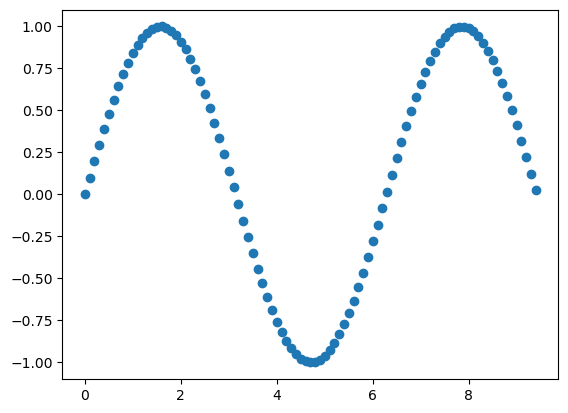

In [36]:
# on initialise deux séries qui feront office d'abcsisses et d'ordonnées:
x = np.arange(0, 3 * np.pi, 0.1) # valeurs allant de 0 à 9.4, avec un pas de 0.1
y_sin = np.sin(x) 

# On affiche les points
plt.scatter(x, y_sin);

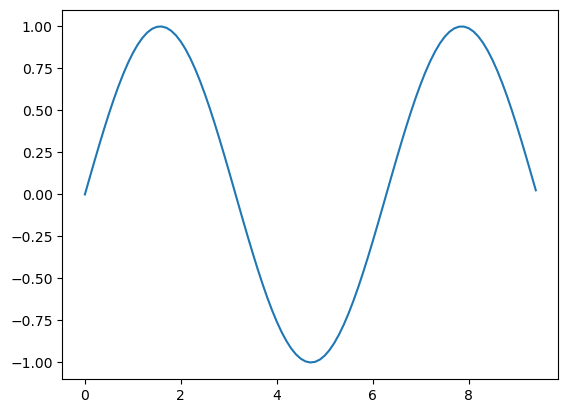

In [37]:
# On affiche la courbe

plt.plot(x, y_sin);

On peut enrichir un graphique avec des labels d'axes, un titre et une légende — indispensable quand on partage ses résultats :

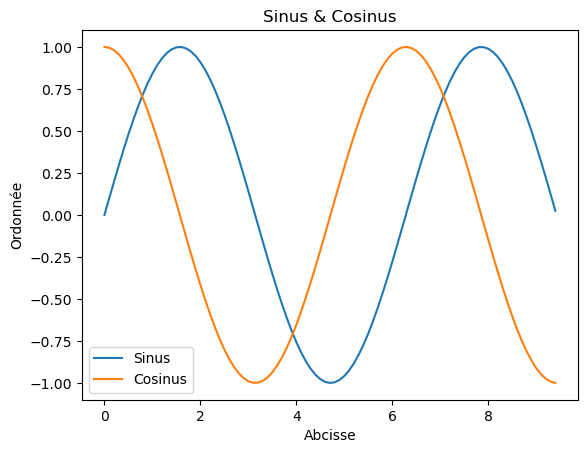

In [38]:
x = np.arange(0, 3 * np.pi, 0.1) # valeurs allant de 0 à 9.4, avec un pas de 0.1
y_sin = np.sin(x) 
y_cos = np.cos(x)

# Afficher les courbes
plt.plot(x, y_sin)
plt.plot(x, y_cos)
plt.xlabel('Abcisse')
plt.ylabel('Ordonnée')
plt.title('Sinus & Cosinus')
plt.legend(['Sinus', 'Cosinus']);

### Subplots : plusieurs graphiques côte à côte

Comparer visuellement deux distributions ou deux variables est beaucoup plus parlant quand les graphiques sont côte à côte.

La méthode `subplot(lignes, colonnes, position)` permet de disposer plusieurs graphiques dans une même figure. **Attention** : la position est numérotée **à partir de 1** (pas de 0), de gauche à droite et de haut en bas :

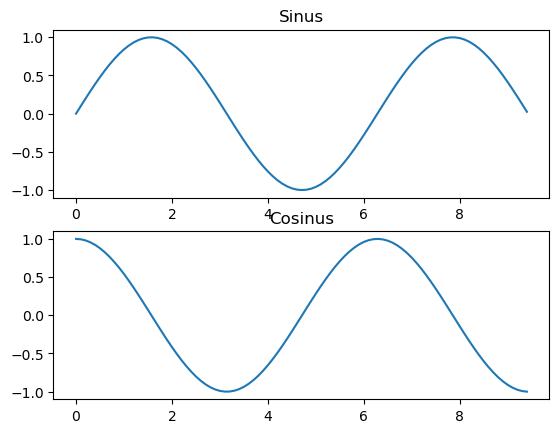

In [39]:
x = np.arange(0, 3 * np.pi, 0.1) # valeurs allant de 0 à 9.4, avec un pas de 0.1
y_sin = np.sin(x) 
y_cos = np.cos(x)

# On déclare un grille avec un colonne et deux lignes
# Le dernier paramètre indique quelle est la zone active de la grille
plt.subplot(2, 1, 1)

# Première courbe
plt.plot(x, y_sin)
plt.title('Sinus')

# Deuxième courbe:zone 2 active
plt.subplot(2, 1, 2)
plt.plot(x, y_cos)
plt.title('Cosinus');

Plus de détails dans la [documentation subplot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplot.html).

## Seaborn

Seaborn est une surcouche de Matplotlib qui produit des graphiques **plus élégants par défaut**, avec moins de code. Il est particulièrement adapté aux graphiques statistiques (distributions, relations entre variables, comparaisons de groupes).

On utilisera beaucoup Seaborn dans les modules suivants pour l'exploration des données.

<Axes: >

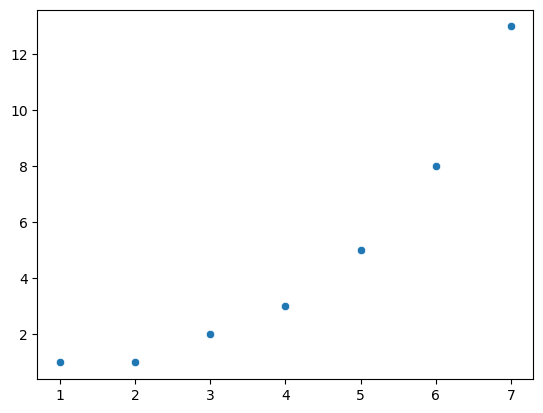

In [40]:
import seaborn as sns

y_fib = [1,1,2,3,5,8,13]
x_fib = range(1,len(y_fib)+1)

sns.scatterplot(x=x_fib, y=y_fib)

Seaborn offre de nombreuses possibilités de configuration. Le concept de **contexte** (`"paper"`, `"notebook"`, `"talk"`, `"poster"`) permet d'adapter automatiquement la taille des éléments graphiques selon l'usage :

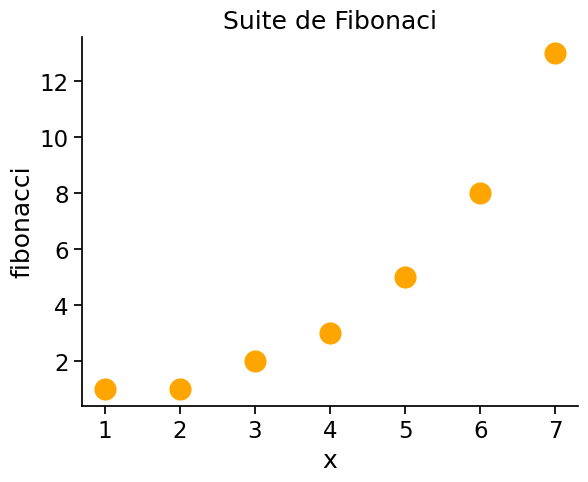

In [41]:
y_fib = [1,1,2,3,5,8,13]
x_fib = range(1,len(y_fib)+1)

# Seaborn définit le concept de "contexte", qui permet de définir des propriétés globales.
# Il existe quatre contextes: “paper”, “notebook”, “talk” et “poster”
# On change la taille des caractères dans le contexte "notebook"
sns.set_context("notebook", font_scale=1.5)

# Changer la taille des points et leur couleur
ax = sns.scatterplot(x=x_fib, y=y_fib, s=300, color='orange')

# "Décorer" le graphique
ax.set(title="Suite de Fibonaci", xlabel="x", ylabel="fibonacci")

# Supprimer le cadre en haut et à droite
sns.despine(top = True, right = True);

Text(0.5, 1.0, 'Cos')

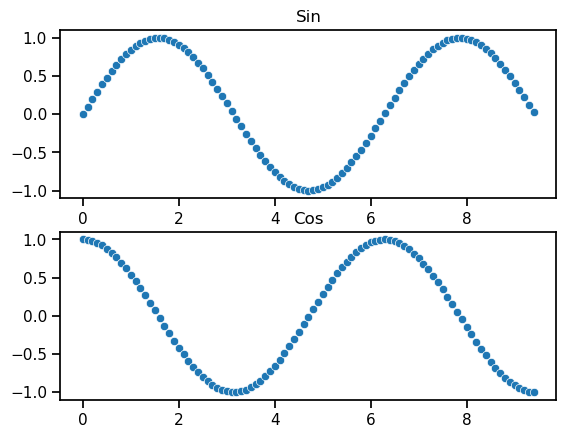

In [42]:
# On réinitialise la taille des caractères dans le contexte "notebook"
sns.set_context("notebook", font_scale=1)

x = np.arange(0, 3 * np.pi, 0.1)
y_sin = np.sin(x) 
y_cos = np.cos(x)

# On déclare un grille avec un colonne et deux lignes
fig, axes = plt.subplots(2, 1)

ax1 = sns.scatterplot(x=x, y=y_sin, ax=axes[0])
ax2 = sns.scatterplot(x=x, y=y_cos, ax=axes[1])

ax1.set_title("Sin")
ax2.set_title("Cos")


> **En résumé :** NumPy vous donne la vitesse de calcul (opérations vectorisées, pas de boucles `for`). Matplotlib et Seaborn vous donnent les yeux pour comprendre vos données. Dans les modules suivants, vous utiliserez Pandas (construit sur NumPy) et Seaborn (construit sur Matplotlib) — mais les fondations sont ici.